<a href="https://colab.research.google.com/github/MatteoBaraldi/Machine-Learning-for-Bioengineering/blob/main/MOD-2/01_Clustering/exercise_density_clustering_solved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Density based clustering methods

In this practice you will:
- implement the clustering method presented in the paper: Rodriguez, Alex, and Alessandro Laio. “Clustering by Fast Search and Find of Density Peaks.” Science 344, no. 6191 (2014): 1492–96. https://doi.org/10.1126/science.1242072.
- apply it to the MNIST dataset
- apply the DBSCAN method on the MNIST dataset
- learn how clustering performances with these two methods are affected by the parameters of the algorithms

## 0. Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans #import KMeans algorithm
from sklearn.cluster import DBSCAN #import DBSCAN algorithm
from sklearn.preprocessing import StandardScaler #import algorithm to standardize data
from sklearn.metrics.pairwise import pairwise_distances #algorithm to compute all distances between points
from sklearn.datasets import make_blobs #function used to generate sinthetic dataset
from sklearn.metrics import adjusted_rand_score #ARI

## 1. Create a synthetic dataset

In [ ]:
mean1 = [1, 6] #define the center of the first cluster
cov1 = [[0.5, 0.0],
        [0.0, 0.5]] #covariance matrix of the first cluster
X1 = np.random.multivariate_normal(mean1, cov1, 120) #generate 120 random samples distributed using a Gaussian using mean and cov
mean2 = [9, 7] #=
cov2 = [[2.5, 1.8],
        [1.8, 1.5]]
X2 = np.random.multivariate_normal(mean2, cov2, 180)
mean3 = [-4, 4] #=
cov3 = [[4.2, -2.4],
        [-2.4, 4.0]]
X3 = np.random.multivariate_normal(mean3, cov3, 100)
X = np.vstack([X1, X2, X3]) #stacks vertically the 3 matrices building a unified dataset of 400 rows and 2 columns
y_true = np.array([0]*len(X1) + [1]*len(X2) + [2]*len(X3)) #create ground truth, 120 0, 180 1, 100 2
feature_names = ['feat_1', 'feat_2'] #names for the features
scaler = StandardScaler() #initialize the standardization tool
X_scaled = scaler.fit_transform(X) #firstly it computes mean and std dev and then transforms data subtracting the mean and dividing by the std dev
pd.DataFrame(X_scaled, columns=feature_names).describe().loc[["mean", "std"]] #convert the std matrix in pandas df, compute statistic and isolate mean and std dev
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    s=25, #dot dimensions
    alpha=0.7 #transparency
)
plt.xlabel(feature_names[0] + " (scaled)")
plt.ylabel(feature_names[1] + " (scaled)")
plt.title("Synthetic dataset")
plt.show()

## 2. Clustering based on density peaks

Write a function to calculate for each point in the dataset:
* the local density, **rho**, defined as the number of samples within a given distance epsilon;
* the index of the closest sample with higher density, **inds_closest_higher_rho**. For the sample with highest density set this value to -1;
* the distance to the closest sample with higher density, **delta**.

The function should returns the arrays rho, inds_closest_higher_rho, and delta, and it should plot delta as a function of rho. Test the function using the synthetic dataset, and values of epsilon equal to 0.1, 1, and 10. How does the plot change ? What is the optimal value ?

In [ ]:
def density_peaks(X, eps): #define density peak function
    D = pairwise_distances(X) #compute a matrix of L2 distances between points
    rho = np.sum(D < eps, axis = 1) #compute a boolean matrix of y/n, sums the values per row, compute the density locally for each point
    inds_maxmin_rho = np.argsort(rho)[::-1] #order the points in decreasing order and and the first one is the most dense
    delta = np.zeros(len(rho)) #initialize a zeros array to store distances between each point and the closest high density point to that point
    delta[inds_maxmin_rho[0]] = np.max(D) #for the highest density point we assign the highest distance computed
    inds_closest_higher_rho = -1*np.ones(len(rho), dtype = int) #initialize a -1s array with all the "fathers density" of each point
    for ind in range(1, len(rho)): #from the highest density point to the lowest
        ind_sample = inds_maxmin_rho[ind] #takes the index of the actual point
        inds_higher_density = inds_maxmin_rho[:ind] #isolate all the points with an highest density than the actual point
        inds_closest_higher_rho[ind_sample] = inds_higher_density[ #compute the distance between the actual point and all the higher density points , finds the closest one and saves it
            np.argmin(D[ind_sample, inds_higher_density])
        ]
        delta[ind_sample] = np.min(D[ind_sample, inds_higher_density]) #save in delta the lowest distance just computed
    f = plt.figure()
    ax = f.add_subplot(1,1,1)
    ax.plot(rho, delta, 'o')
    return rho, delta, inds_closest_higher_rho

In [ ]:
r, d, inds = density_peaks(X, 1.0)

Write a function that takes as inputs the arrays produced by the previous function, and threshold values for rho, **min_rho**, and delta, **min_delta**. The function should:
* define as cluster centers all the points with rho > min_rho and delta > min_delta. I suggest to highlight the cluster centers in a plot of delta Vs rho, to check that the correct samples were selected;
* assign each point to the same cluster of its closest sample of higher density. To do this I suggest to:
  * assign a cluster label to the cluster centers
  * make a cycle over samples in decreasing order of density
      * if the sample does not have a cluster label already assigned to it, use the cluster label of its closest sample of higher density

The function should return the labels of the clusters. Apply the function to the synthetic data, and plot the data using different colors for the clusters. Define the values of min_rho and min_delta based on the plot produced by the previous function.

In [ ]:
def clustering_dp(rho, delta, inds_closest_higher_rho, min_rho, min_delta): #define the clustering function
    inds_centers = np.logical_and(rho > min_rho, delta > min_delta) #find the points that are over both thresholds (outliers)
    f = plt.figure() #initialize new graph
    ax = f.add_subplot(1,1,1)
    ax.plot(rho, delta, 'o') #new scatter plot of all points in the decision graph space
    ax.plot([min_rho, np.max(rho)], [min_delta, min_delta], 'k:') #define the borders of the thresholds imposed
    ax.plot([min_rho, min_rho], [min_delta, np.max(delta)], 'k:')
    ax.plot(rho[inds_centers], delta[inds_centers], 'ro') #red points on the points found to be centers
    labels = -1*np.ones(len(rho), dtype = int)
    labels[np.where(inds_centers)[0]] = np.arange(np.sum(inds_centers)) #finds the centers and gives them a number progressively
    for ind_sample in np.argsort(rho)[::-1]: #studies all points in decreasing density order and assign
        if labels[ind_sample] == -1: #checks if the actual point is not a cluster center (still -1)
            labels[ind_sample] = labels[inds_closest_higher_rho[ind_sample]] #assigns the point the same label as the closest high density center
    return labels

In [ ]:
clustering_dp(r, d, inds, 10.0, 3.0)

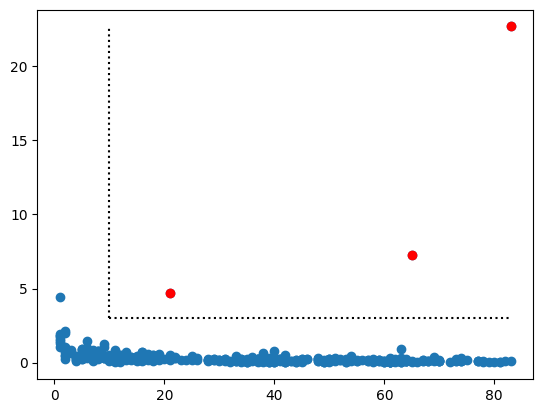

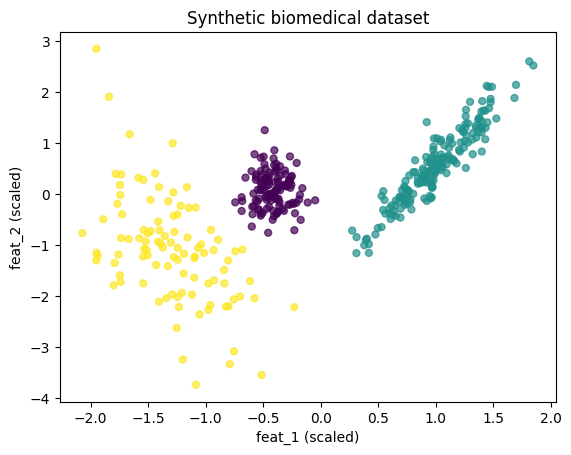

In [ ]:
labels = clustering_dp(r, d, inds, 10.0, 3.0) #calls the function with the density vector, the distance vector and the labels vector
f = plt.figure()
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    s=25,
    c=labels,
    alpha=0.7
)
plt.xlabel(feature_names[0] + " (scaled)")
plt.ylabel(feature_names[1] + " (scaled)")
plt.title("Synthetic biomedical dataset")
plt.show()

## 3. Clustering of the MNIST dataset based on density peaks

The MNIST dataset includes images of hand-written digits. Each image is 8x8. The block of code below load the data, **X**, the correct labels, **y**, and it plots a random image from the dataset.

* Use the functions defined before to identify possible candidates as cluster centers.Modify the value of epsilon to get a number of isolated density peaks around 10-15
* Perform the clustering
* Compute the adjusted rank index of the clustering results
* Plots some examples of images for all the clusters identified

In [ ]:
images = datasets.load_digits() #loads in memory the dataset of digits
X = images['data'] #estrae features
n_images = X.shape[0] #looking at the dimension of the first digit we understand the number of images
y = images['target'] #estrae ground truth
print('Number of images:', n_images)
X_images = X.reshape(n_images, 8, 8) #transform the flat bidimensional matrix into a 8x8 in 3D
ind = np.random.randint(n_images) #generate a random
plt.imshow(X_images[ind], cmap='grey') #takes the 8x8 of the samples randomed
plt.title(y[ind])

In [ ]:
# this block of code imports a different dataset with images at higher resolution. I suggest to use the previous one,
# and then maybe explore this one. In case remember that you need to adjust the parameters of the algoriths,
# as the average distance between samples would be significanly different for these images
from sklearn.datasets import fetch_openml
n_images = 1000 # I downsample the original dataset to this number
X,y = fetch_openml('mnist_784', return_X_y=True)
inds = np.random.choice(np.arange(len(y)).astype(int), n_images)
X = X.to_numpy()
y = y.to_numpy()
X = X[inds,:]
y = y[inds]
n_images = X.shape[0]
X_images = X.reshape(n_images, 28, 28)
X = X_images.reshape(n_images, 28 * 28)
print('Number of images:', n_images)
ind = np.random.randint(n_images)
plt.imshow(X_images[ind], cmap='grey')
plt.title(y[ind])

In [ ]:
def density_peaks(X, eps, metric = 'euclidean'):
    D = pairwise_distances(X, metric = metric) #compute the pairwise distance matrix using the specified metric
    rho = np.sum(D < eps, axis = 1) #calculate local density by counting neighbors within radius eps
    inds_maxmin_rho = np.argsort(rho)[::-1] #sort point indices by density in descending order
    delta = np.zeros(len(rho)) #initialize array for minimum distance to a higher-density point
    delta[inds_maxmin_rho[0]] = np.max(D) #assign maximum distance to the highest density point
    inds_closest_higher_rho = np.zeros(len(rho), dtype = int) #initialize array to store the index of the closest higher-density neighbor
    for ind in range(1, len(rho)): #loop through all remaining points from highest to lowest density
        ind_sample =inds_maxmin_rho[ind]
        inds_higher_density = inds_maxmin_rho[:ind]
        inds_closest_higher_rho[ind_sample] = inds_higher_density[np.argmin(D[ind_sample, inds_higher_density])]
        delta[ind_sample] = np.min(D[ind_sample, inds_higher_density])
    f = plt.figure()
    ax = f.add_subplot(1,1,1)
    ax.plot(rho, delta, 'o')
    return rho, delta, inds_closest_higher_rho

In [ ]:
r, d, inds = density_peaks(X, 25)

In [ ]:
labels = clustering_dp(r, d, inds, 15, 25) #run the density peaks clustering with the specified thresholds
n_example_images = 8
n_clusters = np.max(labels)+1 #total number of identified clusters
for i_cluster in range(n_clusters): #iterate through each identified cluster to visualize sample images
    i_images = np.arange(n_images)[labels == i_cluster] #get the indices of all images belonging to the current cluster
    i_examples = np.random.choice(i_images, n_example_images) #randomly select a subset of images from this cluster to display
    f = plt.figure()
    for j, i_image in enumerate(i_examples): #plot each selected sample image in a side-by-side subplot layout
        ax = f.add_subplot(1, n_example_images, j+1)
        ax.imshow(X_images[i_image], cmap='grey')
ri = adjusted_rand_score(labels, y)
print('Number of clusters = ', n_clusters)
print('Adjuested rank score =', ri)

## 4. Clustering of the MNIST dataset using DBSCAN

Clusterize the same data using the DBSCAN algorithm. Set epsilon to 20 and the minimum number of samples to 10. Compute the adjusted rank index excluding the samples labelled ad noise by DBSCAN.

Estimated number of clusters: 0
Estimated number of noise points: 1000
Adjuested rank score (with the noise "cluster") = 0.0
Adjuested rank score = 1.0


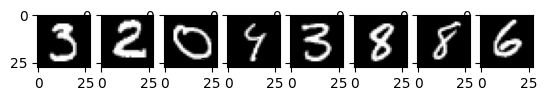

In [ ]:
db = DBSCAN(eps=20, min_samples=10).fit(X) #initialize and fit the DBSCAN clustering model on data X
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

ri = adjusted_rand_score(labels, y) #evaluate overall performance against true targets
print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)
print('Adjuested rank score (with the noise "cluster") =', ri)
inds_no_noise = labels != -1 #filter out noise points to compute ARI exclusively on valid clusters
ri = adjusted_rand_score(labels[inds_no_noise], y[inds_no_noise])
print('Adjuested rank score =', ri)

n_example_images = 8
for i_cluster in range(n_clusters_): #loop through each valid cluster to visualize random sample images
    i_images = np.arange(n_images)[labels == i_cluster]
    i_examples = np.random.choice(i_images, n_example_images)
    f = plt.figure()
    for j, i_image in enumerate(i_examples): #display the sample images side-by-side
        ax = f.add_subplot(1, n_example_images, j+1)
        ax.imshow(X_images[i_image], cmap='grey')

i_images = np.arange(n_images)[labels == -1]
i_examples = np.random.choice(i_images, n_example_images)
f = plt.figure()
for j, i_image in enumerate(i_examples): #display the noise sample images side-by-side
    ax = f.add_subplot(1, n_example_images, j+1)
    ax.imshow(X_images[i_image], cmap='grey')